In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\viraj\Downloads\Python_Diwali_Sales_Analysis-main\Python_Diwali_Sales_Analysis-main\Diwali Sales Data.csv', encoding='unicode_escape')


In [3]:
df.shape

(11251, 15)

In [4]:
 df.head(10)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [6]:
df.drop(['Status','unnamed1'], axis=1, inplace=True)

In [7]:
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [8]:
df.shape
#for comparing before and after the null values are removed

(11251, 13)

In [9]:
df.dropna(inplace=True)

In [10]:
df.shape

(11239, 13)

In [11]:
df['Amount'] = df['Amount'].astype('int')

In [12]:
df['Amount'].dtypes

dtype('int32')

 # **Exploratory data anaylsis**

In [13]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [14]:
df.rename(columns={'Maital_Status':'Marriage'},inplace='True')

In [15]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [16]:
df[['Age','Orders','Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


In [17]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

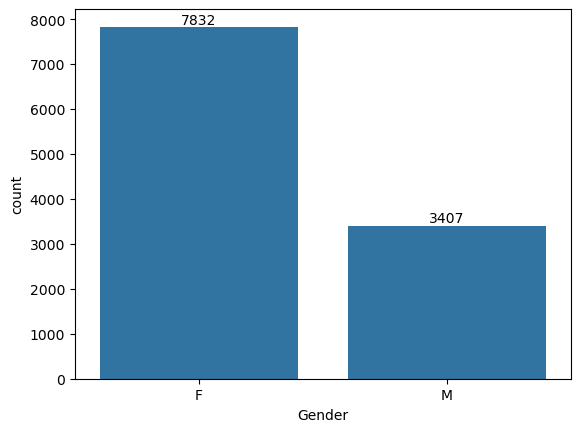

In [20]:
ax = sns.countplot(x = 'Gender',data = df)

for bars in ax.containers:
    ax.bar_label(bars)

In [27]:
df.groupby(['Gender'],as_index=False)['Amount'].sum().sort_values(['Amount'],ascending=False)

,Gender,Amount
0,F,74335853
1,M,31913276


<Axes: xlabel='Gender', ylabel='Amount'>

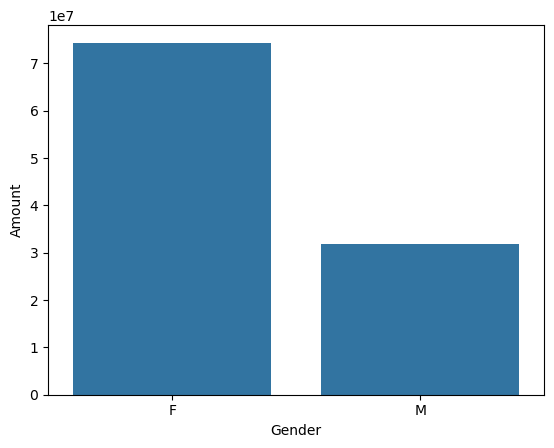

In [31]:
sales_gen = df.groupby(['Gender'],as_index=False)['Amount'].sum().sort_values(['Amount'],ascending=False)

sns.barplot(x='Gender', y='Amount',data = sales_gen)

 This barplot shows that females tend to buy more than men plus women has more purhasing power than men

# **AGE**

In [47]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age_group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [41]:
df.rename(columns={'Age Group':'Age_group'},inplace=True)

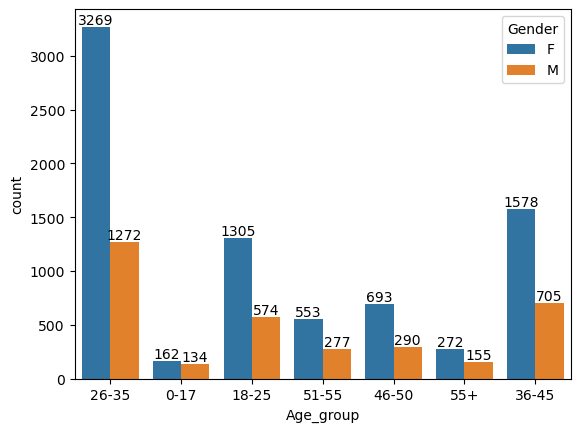

In [48]:
ag = sns.countplot(data = df, x='Age_group', hue='Gender')

for bars in ag.containers:
    ag.bar_label(bars)

Text(0, 0.5, 'Orders')

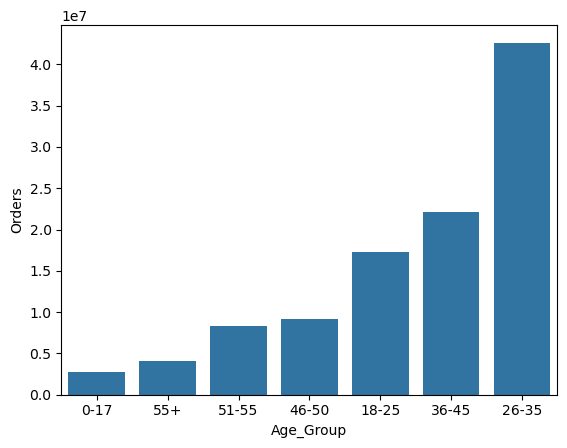

In [64]:
sales_Age = df.groupby(['Age_group'],as_index=False)['Amount'].sum().sort_values(['Amount'],ascending=True)

sns.barplot(x='Age_group',y='Amount',data = sales_Age)
plt.xlabel('Age_Group')
plt.ylabel('Orders')

**With this we can see that generation 26-35 tend to spend more because of freedom in money and energy in life and second most age group 36-45 have kids and parents**

# State

In [66]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age_group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

## Orders/States barplot

Text(0, 0.5, 'Orders')

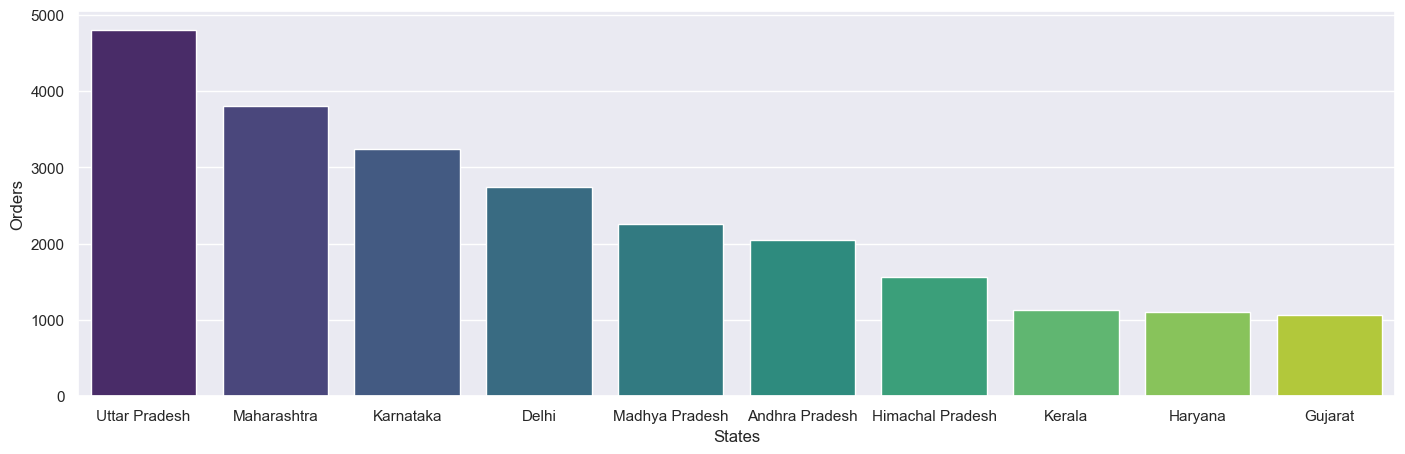

In [99]:
sales_states = df.groupby(['State'],as_index=False)['Orders'].sum().sort_values('Orders',ascending=False).head(10)

sns.set(rc={'figure.figsize':(17,5)})
sns.barplot(data=sales_states,x='State',y='Orders',hue='State' ,palette='viridis',legend=False) #palette is color function in seaborn
plt.xlabel('States')
plt.ylabel('Orders')

## Amount/state barplot

Text(0, 0.5, 'Amount')

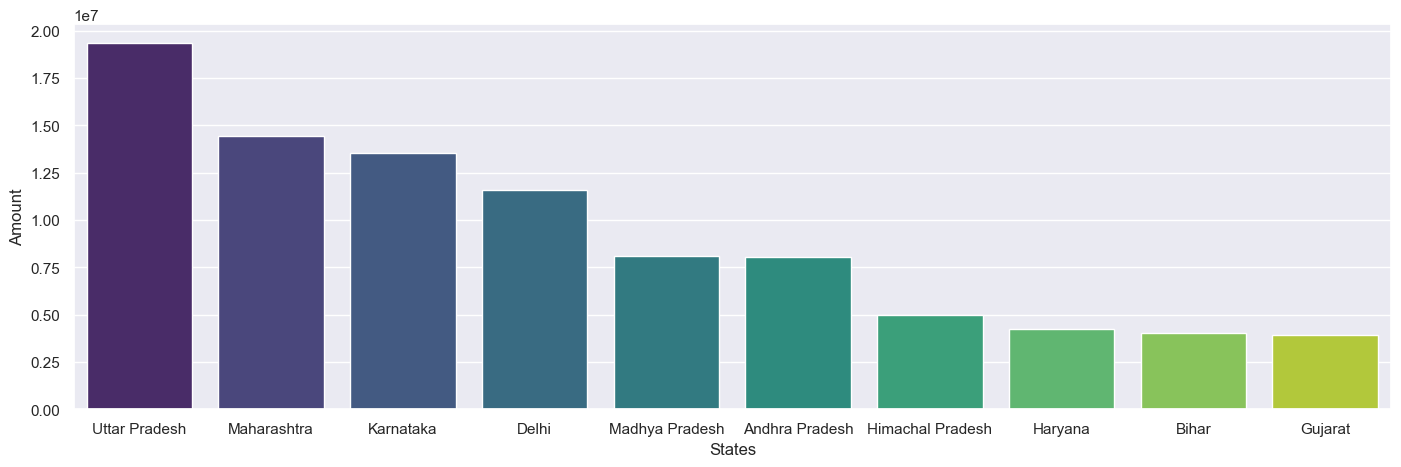

In [147]:
#Amount/state barplot
sales_states = df.groupby(['State'],as_index=False)['Amount'].sum().sort_values('Amount',ascending=False).head(10)

sns.set(rc={'figure.figsize':(17,5)})
sns.barplot(data=sales_states,x='State',y='Amount',hue='State' ,palette='viridis',legend=False)
plt.xlabel('States')
plt.ylabel('Amount')

**From above bargraphs there is significant difference btw no. of orders and purchasing power kerala was 7th in orders list but there purchasing power was lower than haryana and even bihar which ins't even top 10 of ordering list is higher than kerala in the scale of amount used**

# Martial Status

In [102]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age_group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

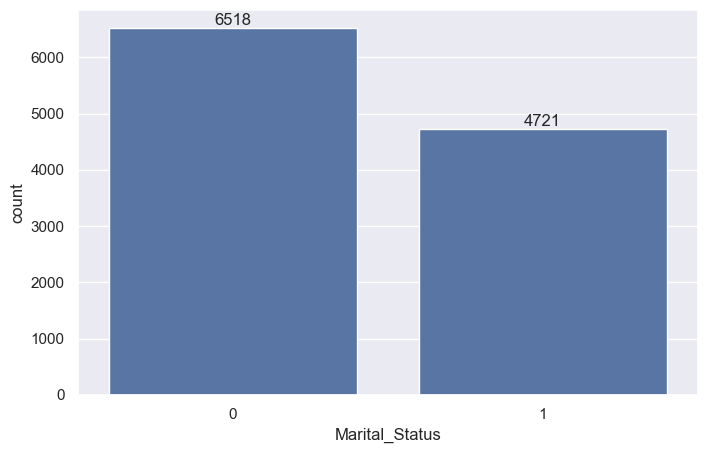

In [110]:
ap = sns.countplot(data= df,x = 'Marital_Status')

sns.set(rc={'figure.figsize':(8,5)})
for bars in ap.containers:
    ap.bar_label(bars)

<Axes: xlabel='Marital_Status', ylabel='Amount'>

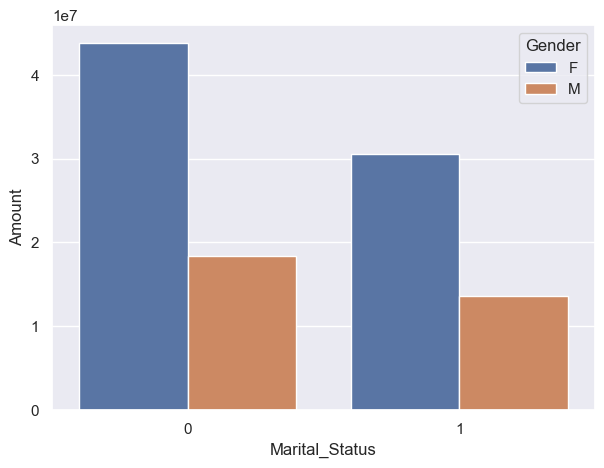

In [117]:
sales_marital_status = df.groupby(['Marital_Status','Gender'],as_index=False)['Amount'].sum().sort_values('Amount',ascending=False)

sns.set(rc={'figure.figsize':(7,5)})
sns.barplot(data=sales_marital_status,x='Marital_Status',y='Amount',hue='Gender')

**married women have more purchasing power but even unmarried women have more purchasing power than married men**

# Occupation


In [118]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age_group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

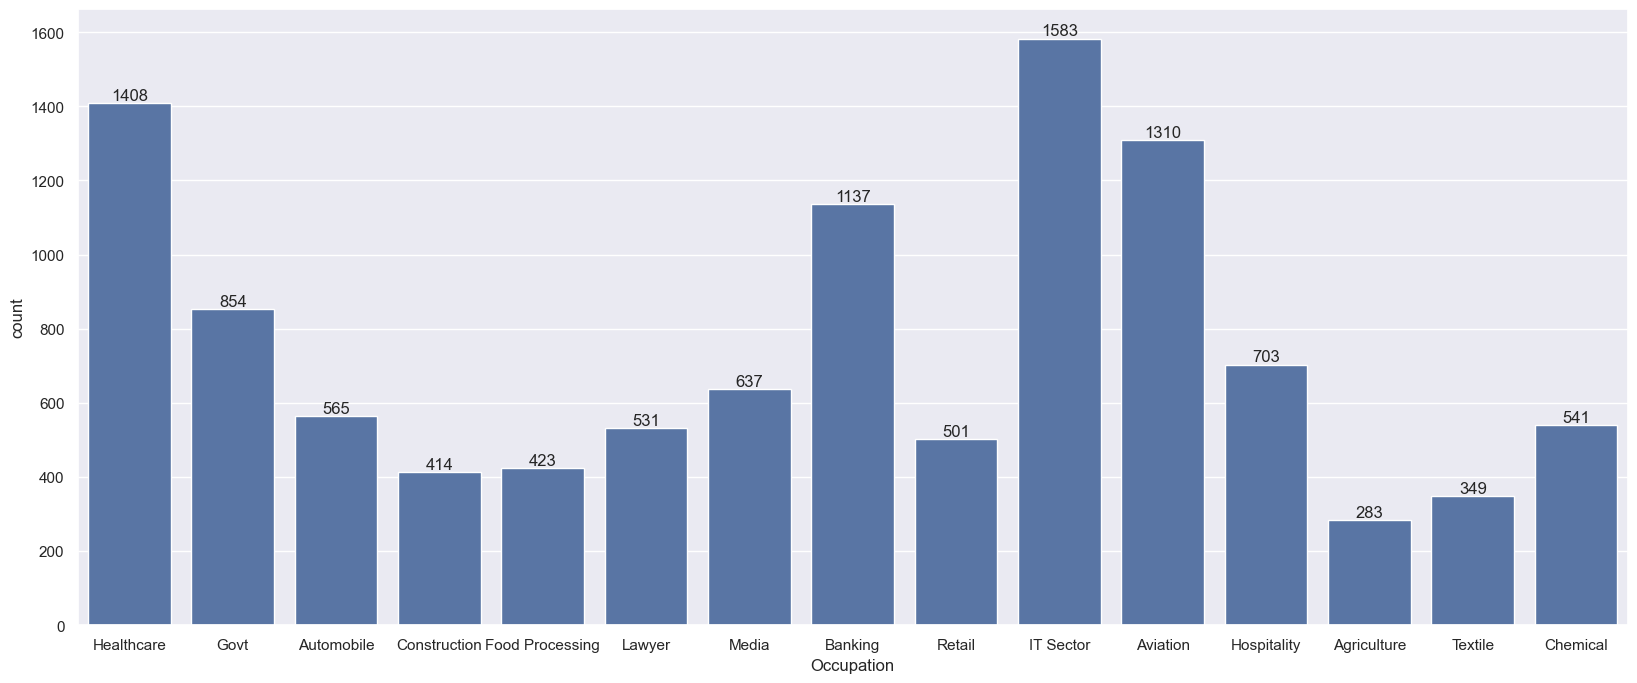

In [136]:
sns.set(rc={'figure.figsize':(20,8)})
ad = sns.countplot(data = df,x='Occupation')

for bars in ad.containers:
    ad.bar_label(bars)

<Axes: xlabel='Occupation', ylabel='Amount'>

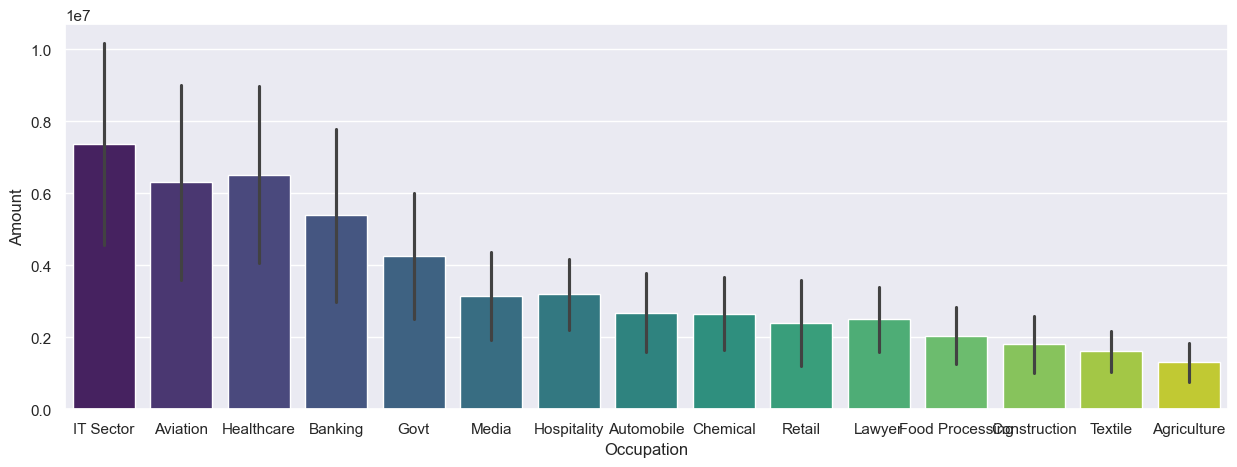

In [153]:
sales_Occupation = df.groupby(['Occupation','Gender'],as_index=False)['Amount'].sum().sort_values('Amount',ascending=False)

sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data=sales_Occupation,x='Occupation',y='Amount',hue='Occupation' ,palette='viridis',legend=False)

**well as expected IT sector would be the highest on based of purchasing power healthcare adn aviation as the runner ups**

# Product Category

In [154]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age_group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

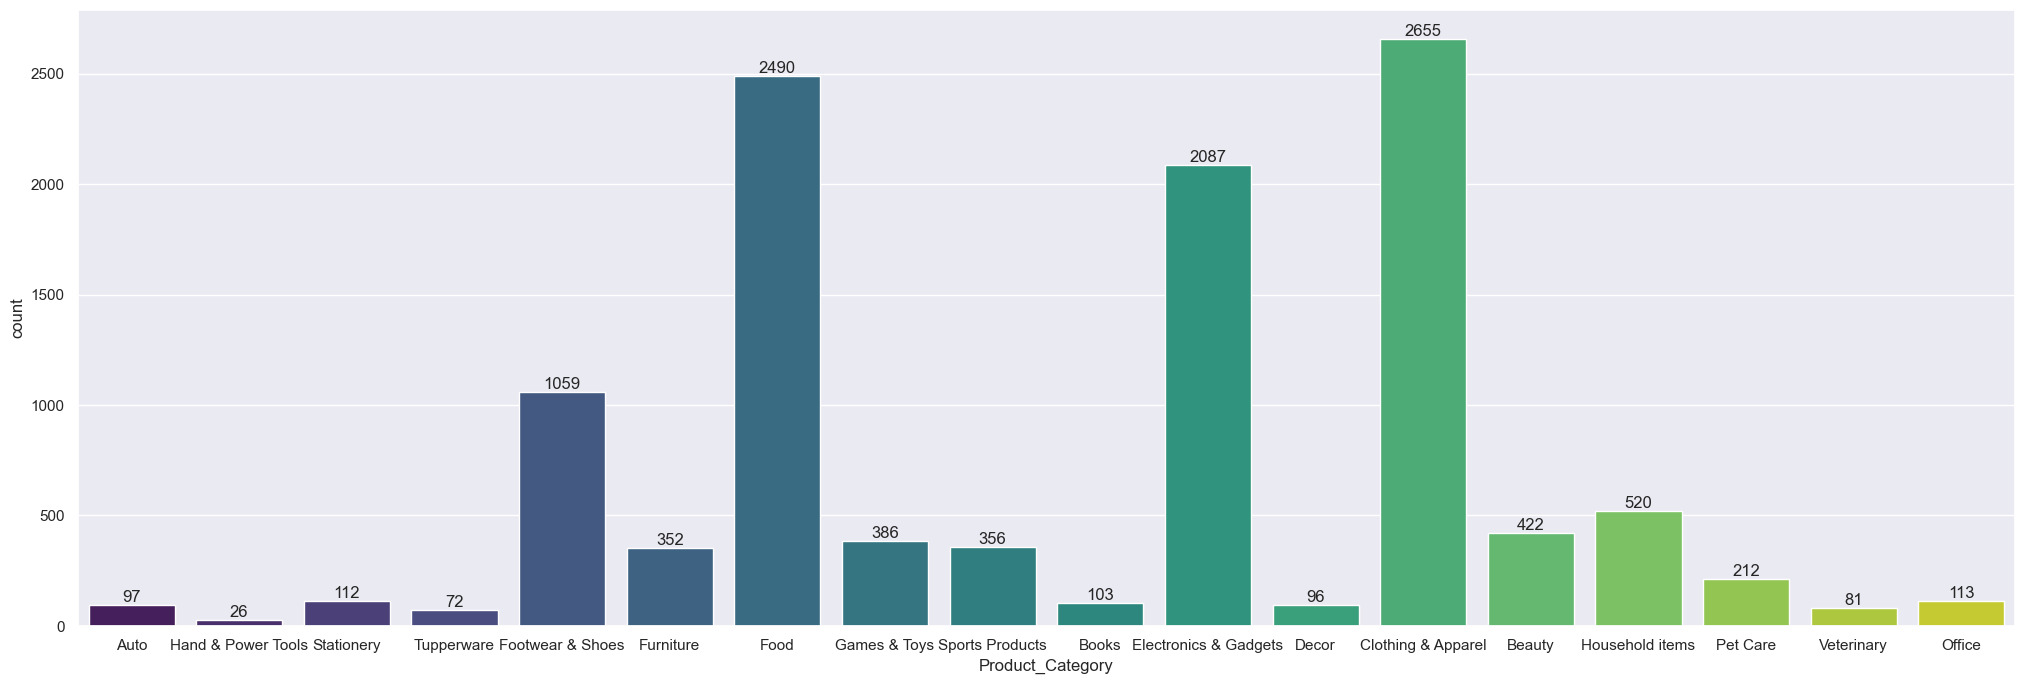

In [167]:
sns.set(rc={'figure.figsize':(25,8)})
ad = sns.countplot(data = df,x='Product_Category',hue='Product_Category' ,palette='viridis',legend=False)

for bars in ad.containers:
    ad.bar_label(bars)

<Axes: xlabel='Product_Category', ylabel='Amount'>

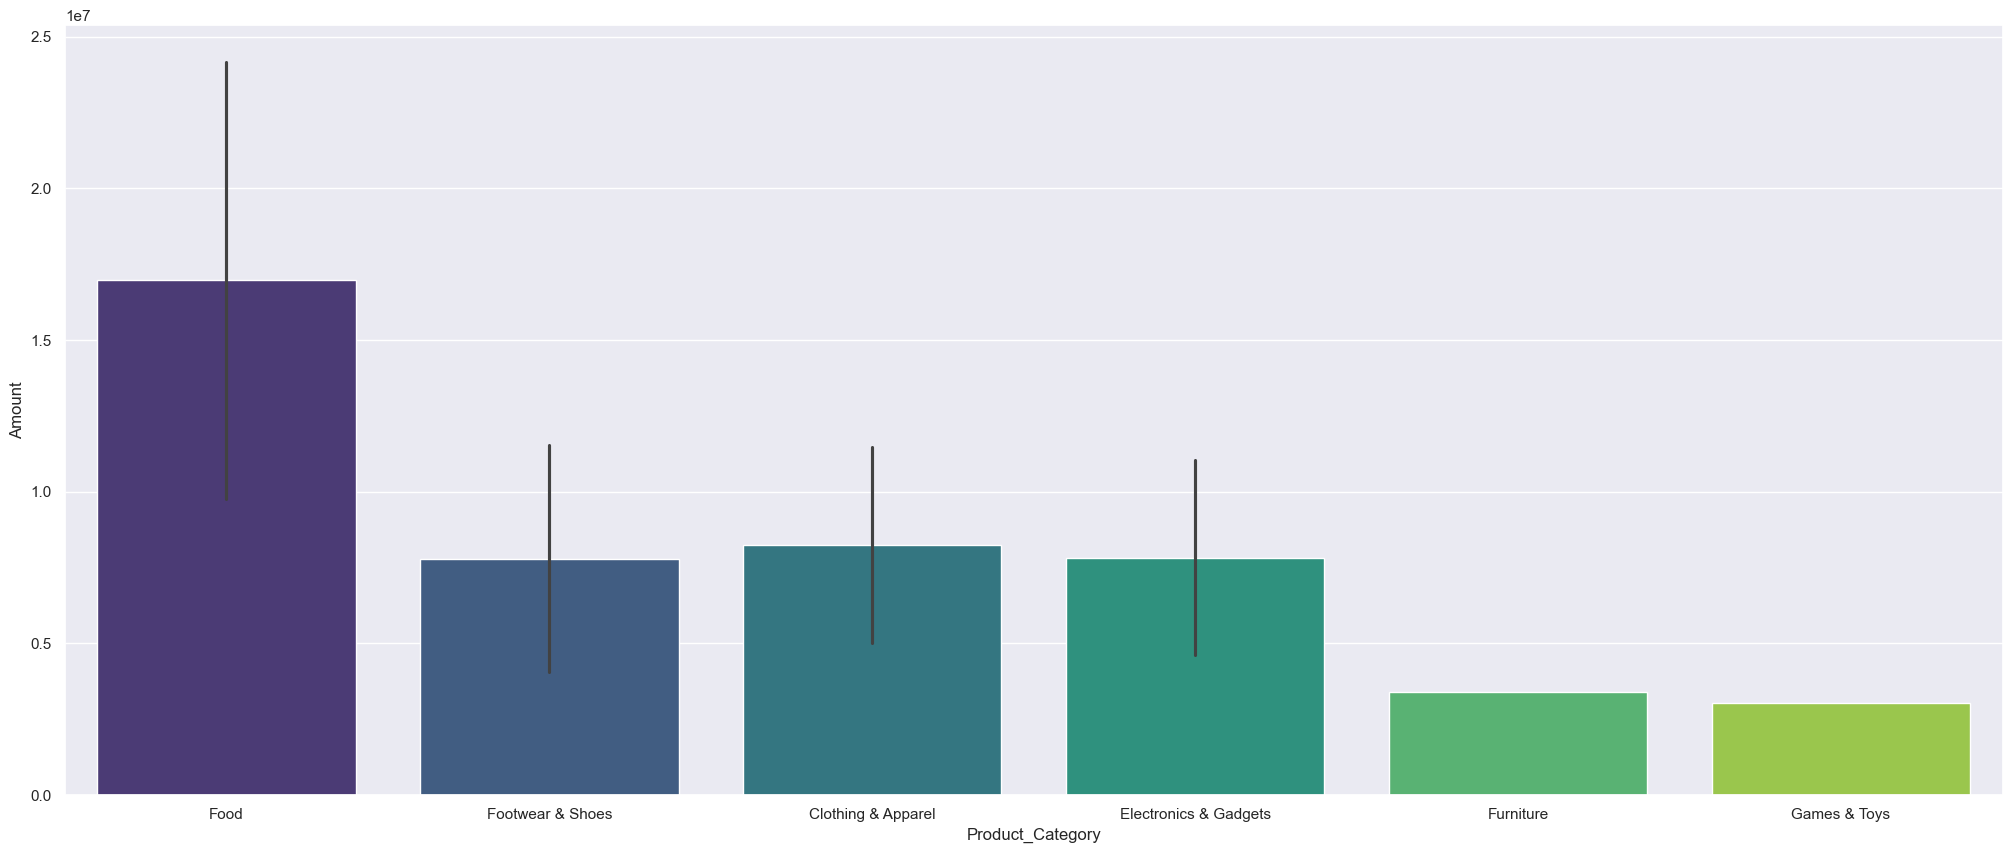

In [173]:
sales_Product_Category= df.groupby(['Product_Category','Gender'],as_index=False)['Amount'].sum().sort_values('Amount',ascending=False).head(10)

sns.set(rc={'figure.figsize':(25,10)})
sns.barplot(data=sales_Product_Category,x='Product_Category',y='Amount',hue='Product_Category' ,palette='viridis',legend=False)

<Axes: xlabel='Product_Category', ylabel='Orders'>

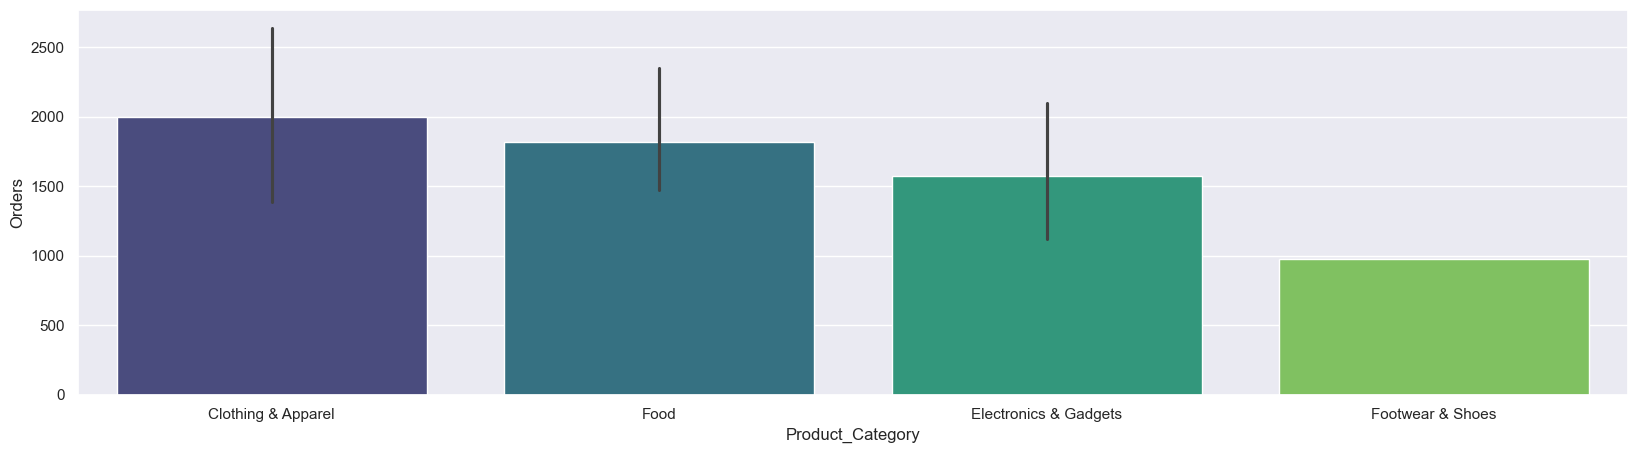

In [180]:
sales_Product_Category= df.groupby(['Product_Category','Orders'],as_index=False)['Orders'].sum().sort_values('Orders',ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data=sales_Product_Category,x='Product_Category',y='Orders',hue='Product_Category' ,palette='viridis',legend=False)

**so with above EDA on the dataset i have see that 26-35 age womne spend more and has the largest markcet that to even Uttar Pardesh and most apending is on food wi